In [1]:
# import basic modules
import sys
import os
import time
import numpy as np
import h5py
import pandas as pd
import scipy
import torch
import matplotlib
import matplotlib.pyplot as plt
import warnings
import pickle
import argparse, gc
from skimage.transform import resize
import random
import time

import torch.multiprocessing as mp
import os
import socket
from torch.cuda.amp import GradScaler
from contextlib import closing
import torch.distributed as dist
# import model
from torch.nn.parallel import DistributedDataParallel as DDP
import numpy as np
import math

# from options import Options
import functools
import random
from torch import autocast
# from eva_clip import create_model_and_transforms, get_tokenizer
import clip
# import timm
torch.backends.cudnn.benchmark=True


# Set some paths: where the preprocessed NSD files live

nsd_path = '/lab_data/hendersonlab/datasets/nsd_preproc'
data_folder = os.path.join(nsd_path, 'data')
labels_folder = os.path.join(nsd_path, 'labels')
stim_folder = os.path.join(nsd_path, 'stimuli')
rois_folder = os.path.join(nsd_path, 'rois')

In [2]:
# Stuff from data_loader_224

OPENAI_CLIP_MEAN = np.array((0.48145466, 0.4578275, 0.40821073), dtype=np.single)[:, None, None]
OPENAI_CLIP_STD = np.array((0.26862954, 0.26130258, 0.27577711), dtype=np.single)[:, None, None]

def load_from_nii(nii_file):
    return nib.load(nii_file).get_fdata()

def listdir(path):
    return [os.path.join(path, x) for x in os.listdir(path)]

def join(*paths):
    return os.path.join(*paths)

def check_between(start_count, end_count, check_idx):
    return (check_idx >= start_count) and (check_idx < end_count)

def normalize_image(input_ndarray):
    # print(input_ndarray.dtype, np.max(input_ndarray), np.min(input_ndarray), input_ndarray.shape)
    # exit()
    image_resized = resize(input_ndarray, (224, 224), preserve_range=True)
    scaled_image = image_resized.astype(np.single).transpose((2, 0, 1))*random.uniform(0.95, 1.05)/(255.0)
    # print(scaled_image.shape, OPENAI_CLIP_STD.shape, OPENAI_CLIP_MEAN.shape, "SHAPES")
    return (scaled_image-OPENAI_CLIP_MEAN)/OPENAI_CLIP_STD

def normalize_image_deterministic(input_ndarray):
    image_resized = resize(input_ndarray, (224, 224), preserve_range=True)
    scaled_image = image_resized.astype(np.single).transpose((2, 0, 1))/(255.0)
    return (scaled_image-OPENAI_CLIP_MEAN)/OPENAI_CLIP_STD

In [3]:
class neural_loader(torch.utils.data.Dataset):
    def __init__(self, arg_stuff):

        # NOTE this is really meant to be used for one subject.
        # It looks like it would accept a list of subs, but will break for > 1.
        
        self.subject_id = arg_stuff.subject_id
        assert(len(self.subject_id)==1)
        if isinstance(self.subject_id, int):
            self.subject_id = list([self.subject_id])
            
        self.neural_activity_path = arg_stuff.neural_activity_path
        self.image_path = arg_stuff.image_path
        # self.image_data = None
        
        self.roi_path = arg_stuff.roi_path
        
        self.transform = normalize_image

        self.all_keys = dict() # Maps subject id to valid COCO_ids
        self.num_stimulus = dict() # Maps subject id to number of stimulus
        self.neural_sizes = dict() # Maps subject id to number of voxels
        self.roi_info = dict()
        self.noise_celing = dict()
        self.double_mask = dict()
        
        self.stim_keys_path = arg_stuff.stim_keys_path

        # Load my dictionary: this has a list of saved keys for all our subjects.
        # Key = COCO ID
        with open(self.stim_keys_path, "rb") as dict_saver:
            all_keys = pickle.load(dict_saver)

        # Define testing set
        # These are coco ids that overlap across all 8 subjects. There are 907 of these.
        testing_set = set.intersection(*[set(_) for _ in list(all_keys.values())]) 
        self.testing_set = sorted(testing_set)
        
        self.complete_keys = all_keys

        # Now figuring out some things specific to each subject...
        for subject in self.subject_id:
            str_subject = str(subject)
            neural_data = h5py.File(self.neural_activity_path.format(str_subject), 'r')

            # all_keys: this is just the TRAINING set, not testing.
            # For the subjects with all trials (1,2,5,7), this will have: 10000 - 907 = 9093 elements
            self.all_keys[str_subject] = [i for i in list(neural_data.keys()) if ((not "mask" == i) and (not i in testing_set))] # What is "mask": no mask in this data

            # Number of training stimuli
            self.num_stimulus[str_subject] = len(self.all_keys[str_subject])

            # This is a dict of the info about ROI defs for this subject
            # This can be used to get masks for your desired areas.
            self.roi_info[str_subject] = np.load(self.roi_path.format(str_subject), allow_pickle=True).item()
            self.noise_celing[str_subject] = self.roi_info[str_subject]['noise_ceiling_avgreps']

            # Number of voxels we have here
            self.neural_sizes[str_subject] = np.sum(self.roi_info[str_subject]['voxel_mask']) # voxel mask: all valid voxels? then how to use roi masks?
            self.double_mask[str_subject] = np.ones(self.neural_sizes[str_subject],dtype=bool) # What is double mask?
            

            # apply voxel mask to neural data and roi mask to match voxel space

            neural_data.close()
            neural_data = None
            gc.collect()
            # Pytorch will fail if you try to use multiprocessing with an open h5py
            # Zero it out
            
            setattr(self, "subj_{}_neural_data".format(str_subject), None) # Why set to None?
            setattr(self, "subj_{}_image_data".format(str_subject), None)
            
        self.all_subjects = sorted(list(self.all_keys.keys()))

    def __len__(self):
        
        # This is TRAINING set length
        if len(self.all_subjects)==1:
            return list(self.num_stimulus.values())[0]
        print("multi subject case", max(list(self.num_stimulus.values())))
        return max(list(self.num_stimulus.values()))

    
    def __getitem__(self, idx):
        # return a dictionary with keys: 'subject_id', 'neural_data', 'image_data'
        # 'neural data': neural data for single subject, shape: (n_voxels, )
   
        # this is how we get TRAINING set
        
        all_images = []
        all_neural = []
        for subject_idx in self.all_subjects:
            
            mask = self.double_mask[subject_idx]

            # if neural and image data already loaded, use that variable
            subject_neural_h5py = getattr(self, "subj_{}_neural_data".format(subject_idx))
            subject_image_h5py = getattr(self, "subj_{}_image_data".format(subject_idx))

            # otherwise load them here...
            if subject_neural_h5py is None:
                # print('Loading neural data: %s'%self.neural_activity_path.format(subject_idx))
                subject_neural_h5py = h5py.File(self.neural_activity_path.format(subject_idx), 'r')
            else:
                pass

            if subject_image_h5py is None:
                # print('Loading image data: %s'%self.image_path.format(subject_idx))
                subject_image_h5py = h5py.File(self.image_path.format(subject_idx), 'r') # only open the file, notnloading the file to the memory
            else:
                pass
                
            # print(len(subject_neural_h5py), subject_idx)

            # Choosing which index to load 
            # print(idx, self.num_stimulus[subject_idx])
            assert idx <= (self.num_stimulus[subject_idx]-1)
            curidx = idx

            
            # this bottom part is if you had more subs with different numbers of trials.
            # if idx > (self.num_stimulus[subject_idx]-1):
            #     curidx = random.randint(0, self.num_stimulus[subject_idx]-1)
            # else:
            #     curidx = idx

            # Get the COCO ID for this image. It is a key into my h5py file
            neural_key = self.all_keys[subject_idx][curidx]

            # print([idx, neural_key])
            
            # apply ROI mask here. can be nothing if mask is all ones
            selected_neural = subject_neural_h5py[neural_key][:][mask] # get real data and load to memory
            
            selected_image = subject_image_h5py[neural_key][:]

            # print(f'Selected neural: {selected_neural.shape}')
            # print(f'Selected image: {selected_image.shape}')
            
            if not (self.transform is None):
                selected_image = self.transform(selected_image)
            else:
                assert False
                
            all_images.append(np.copy(selected_image))
            all_neural.append(np.copy(selected_neural))

        all_neural = np.concatenate(all_neural)
        
        return_subjects = np.array([int(x) for x in self.all_subjects])

        # print(f'All neural: {all_neural.shape}')
        # print('returning')
        
        return {"subject_id":torch.from_numpy(return_subjects), \
                "neural_data": torch.from_numpy(all_neural), \
                "image_data": torch.from_numpy(np.array(all_images))}

    def get_item_test(self, idx):

        # This is how we get TESTING set
        
        all_images = []
        all_neural = []
        for subject_idx in self.all_subjects:
            mask = self.double_mask[subject_idx]

            subject_neural_h5py = getattr(self, "subj_{}_neural_data".format(subject_idx))
            subject_image_h5py = getattr(self, "subj_{}_image_data".format(subject_idx))

            if subject_neural_h5py is None:
                subject_neural_h5py = h5py.File(self.neural_activity_path.format(subject_idx), 'r')
            else:
                pass

            if subject_image_h5py is None:
                subject_image_h5py = h5py.File(self.image_path.format(subject_idx), 'r')
            else:
                pass
                
            assert idx <= (len(self.testing_set) - 1)
            curidx = idx
            neural_key = self.testing_set[curidx]

            # print([idx, neural_key])
            
            selected_neural = subject_neural_h5py[neural_key][:][mask]
            
            selected_image = subject_image_h5py[neural_key][:]
            selected_image = normalize_image_deterministic(selected_image)
            
            all_images.append(np.copy(selected_image))
            all_neural.append(np.copy(selected_neural))
            
        all_neural = np.concatenate(all_neural)
        
        return_subjects = np.array([int(x) for x in self.all_subjects])
        
        return {"subject_id": torch.from_numpy(return_subjects), \
                "neural_data": torch.from_numpy(all_neural), \
                "image_data": torch.from_numpy(np.array(all_images))}

In [4]:
import argparse

n_pix = 224

# Create namespace and set attributes
args = argparse.Namespace()
args.subject_id = [1]
args.neural_activity_path = os.path.join(data_folder, 'S{}_betas_avg_bigmask_dict.hdf5')
args.image_path = os.path.join(stim_folder, 'S{}_stimuli_%d_dict.hdf5'%n_pix)
args.roi_path = os.path.join(rois_folder, 'S{}_voxel_roi_info.npy')
args.stim_keys_path = os.path.join(stim_folder, "all_keys.pkl")

# args.epochs = 100
args.epochs = 1
args.batch_size = 256
args.lr_init = 3e-4
args.lr_decay = 5e-1
args.weight_decay=1.5e-2

In [5]:
loader = neural_loader(args)
n_voxels = loader.neural_sizes[str(args.subject_id[0])]

In [69]:
diter = iter(loader)
batch = next(diter)
batch.keys()

dict_keys(['subject_id', 'neural_data', 'image_data'])

In [70]:
batch['image_data'].shape, batch['neural_data'].shape

(torch.Size([1, 3, 224, 224]), torch.Size([19738]))

In [71]:
# make dataloader
neural_train_loader = torch.utils.data.DataLoader(loader, \
                                            batch_size=args.batch_size, \
                                            shuffle=False, \
                                            num_workers=0, \
                                            drop_last=False)

In [72]:
len(neural_train_loader)

36

In [73]:
# from BrainSCUBA / model.py
# this is just the linear projection layer. CLIP to voxel space.
class soft_quantizer_v3(torch.nn.Module):
    def __init__(self, num_higher_output=1000, num_prototypes=4, embed_dim=512, clip_offset=5.0, max_norm=10.0):
        super().__init__()
        self.linear = torch.nn.Linear(embed_dim, num_higher_output)
    def forward(self, image_vectors):
        # image_vectors should be pre_normalized
        return self.linear(image_vectors)


In [74]:
# From BrainSCUBA / training_ICLR.py

def shuffle_shift(input_image, extent=4):
    offset_x = random.randint(-extent, extent)
    offset_y = random.randint(-extent, extent)
    orig_shape = input_image.shape
    temp = input_image[:,:, max(0,offset_x):min(orig_shape[2], orig_shape[2]+offset_x), max(0,offset_y):min(orig_shape[3], orig_shape[3]+offset_y)]
#     temp = torch.nn.functional.pad(temp, (max(0,offset_y), max(0, -offset_y), max(0,offset_x), max(0, -offset_x)), mode='replicate')
    temp = torch.nn.functional.pad(temp, (max(0, -offset_y),max(0,offset_y), max(0, -offset_x), max(0,offset_x)), mode='replicate')
    return temp
# not sure we need this bit ^
# it's a data augmentation step. might hurt in some areas...

model_name = "EVA02-CLIP-B-16"
pretrained = "eva_clip" 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
feature_extractor, _ = clip.load("ViT-B/32", device=device)

del feature_extractor.transformer
torch.cuda.empty_cache()
feature_extractor.eval()
projector = soft_quantizer_v3(num_higher_output=n_voxels)
projector = projector.to(device)
projector.train()

cuda


soft_quantizer_v3(
  (linear): Linear(in_features=512, out_features=19738, bias=True)
)

In [75]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.AdamW(projector.parameters(), \
                              lr=args.lr_init, \
                              weight_decay=args.weight_decay) 
# weight decay here: this implements L2 penalty, like ridge

In [76]:
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0.015
)

In [77]:
# loop over epochs: in each epoch, we're passing over whole training set.
# i am only doing one for testing this...
start_epoch = 0
max_steps = len(neural_train_loader) 
# max_steps = 5; # for debugging, stop early

for epoch in range(start_epoch, args.epochs):
    print(f"Epoch {epoch+1} of {args.epochs}")

    # adjust my learning rate, according to decay function
    decay_rate = args.lr_decay
    new_lrate = args.lr_init * (decay_rate ** (epoch / args.epochs))

    # setting new learning rate
    for param_group in optimizer.param_groups:
        param_group['lr'] = new_lrate

    # keeping track of losses, throughout my epoch
    total_losses = 0
    cur_iter = 0

    # train_sampler.set_epoch(epoch)
    # doing steps over dataloader now

    for step, data_stuff in enumerate(neural_train_loader):

        st = time.time()
        
        # if np.mod(step, 50)==0:
        #     # print(step, max_steps)
        if step > max_steps:
            # print(step)
            break
            
        neural_data = data_stuff["neural_data"].to(device)
        image_data = data_stuff["image_data"][:,0,:,:,:].to(device) # the 1st dim is zero here

        # print(neural_data.shape)
        # print(image_data.shape)
        
        # neural_data = data_stuff["neural_data"].to(output_device, non_blocking=True) # Flat tensor already
        # image_data = data_stuff["image_data"][:,0].to(output_device, non_blocking=True) # collapse along batch
        
        optimizer.zero_grad(set_to_none=True)
        with torch.no_grad():
            # features = feature_extractor.encode_image(image_data)
            features = feature_extractor.encode_image(shuffle_shift(image_data)+torch.randn_like(image_data)*0.05)
            features = features/features.norm(dim=-1, keepdim=True)
        predicted = projector(features.float())
        
        loss = criterion(predicted, neural_data)
        # if rank==0:
        #     total_losses += loss.detach()
        #     cur_iter += 1
            
        loss.backward()
        optimizer.step()

        elapsed = time.time() - st
        # if np.mod(step, 50)==0:
        #     print('step took: %.5f s'%elapsed)


Epoch 0 of 10
Epoch 1 of 10
Epoch 2 of 10
Epoch 3 of 10
Epoch 4 of 10
Epoch 5 of 10
Epoch 6 of 10
Epoch 7 of 10
Epoch 8 of 10
Epoch 9 of 10


In [78]:
projector

soft_quantizer_v3(
  (linear): Linear(in_features=512, out_features=19738, bias=True)
)

In [79]:
# Now getting ready to evaluate the model...

In [80]:
for name, param in projector.named_parameters():
    print(f"{name}: {param.shape}")
    print(param.data)

linear.weight: torch.Size([19738, 512])
tensor([[ 0.0101, -0.0413,  0.0811,  ...,  0.0184,  0.0364,  0.0377],
        [ 0.0168, -0.0507,  0.0561,  ..., -0.0478, -0.0239,  0.0633],
        [-0.0580,  0.0133,  0.0135,  ..., -0.0213,  0.0330, -0.0147],
        ...,
        [-0.0792,  0.0311,  0.0576,  ...,  0.0259,  0.0345,  0.0009],
        [-0.0139, -0.0059,  0.0791,  ..., -0.0047,  0.0312,  0.0184],
        [ 0.0141, -0.0135, -0.0043,  ..., -0.0088,  0.0607,  0.0272]],
       device='cuda:0')
linear.bias: torch.Size([19738])
tensor([ 0.0174, -0.0053, -0.0266,  ...,  0.0423, -0.0137,  0.0354],
       device='cuda:0')


In [81]:
# try to free-up cuda memory, not sure this is needed
del neural_data, image_data
torch.cuda.empty_cache()

In [ ]:
# Gather the trained model parameters

w_best = projector.linear.weight
b_best = projector.linear.bias

torch.save(projector.state_dict(), f'weights/weights_bs{args.batch_size}_e{args.epochs}_lr{args.lr_init}_decay{args.lr_decay}_wd{args.weight_decay}.pth')

In [83]:
# Gather the test set / features
# I'm doing predictions with the linear layer in this loop.
# could be a better way...

test_neural_data = [] # shape: (test_set_length (907), n_voxels)
# test_image_data = []
test_features = []

test_preds = []

# Get the test set length
test_set_length = len(loader.testing_set)
print(f"Extracting {test_set_length} test samples...")

for idx in range(test_set_length):
    test_item = loader.get_item_test(idx)
    
    test_neural_data.append(test_item['neural_data'].detach().to('cpu'))
    test_image_data = test_item['image_data']
    
    # get CLIP embedding one image at a time.
    feat = feature_extractor.encode_image(test_image_data.to(device)).float()
    # print(feat.shape)
    feat = feat/feat.norm(dim=-1, keepdim=True)
    # make prediction for held-out data here
    # print(feat.shape, w_best.shape, b_best.shape)
    # print(feat.shape, w_best.T.shape, b_best[None,:].shape)

    # run forward model: predict voxel response
    y_pred = feat @ w_best.T + b_best[None,:]
    y_pred = y_pred.detach().cpu()
    # print(y_pred.shape)

    test_preds.append(y_pred)
    # test_features.append(feature_extractor.encode_image(test_image_data.to(device)))

    
    if idx % 100 == 0:  # Progress indicator
        print(f"Processed {idx}/{test_set_length}")

    del feat, test_item, y_pred
    torch.cuda.empty_cache()  # Clear GPU cache
    

# Concatenate all items
test_neural_data = torch.stack(test_neural_data, dim=0).to(device)  # Shape: [test_length, neural_features]
# test_image_data = torch.stack(test_image_data, dim=0)    # Shape: [test_length, num_subjects, channels, height, width]
# test_image_data = test_image_data[:,0,:,:,:].to(device)
test_preds = torch.stack(test_preds, dim=0)[:,0,:].to(device)

print(f"Test set shapes:")
print(test_neural_data.shape)
# print(test_image_data.shape)
print(test_preds.shape)

Extracting 907 test samples...
Processed 0/907
Processed 100/907
Processed 200/907
Processed 300/907
Processed 400/907
Processed 500/907
Processed 600/907
Processed 700/907
Processed 800/907
Processed 900/907
Test set shapes:
torch.Size([907, 19738])
torch.Size([907, 19738])


In [84]:
test_neural_data.shape, test_preds.shape

(torch.Size([907, 19738]), torch.Size([907, 19738]))

In [85]:
# get MSE - this is loss used during trn phase
criterion(test_preds, test_neural_data)

tensor(0.3913, device='cuda:0')

In [86]:
sys.path.insert(0,'/lab_data/hendersonlab/code/utils/')
import stats_utils

In [87]:
# get R2 per voxel
r2_voxels = np.zeros((n_voxels,1))
for vv in range(n_voxels):    
    r2_voxels[vv] = stats_utils.get_r2(test_neural_data[:,vv].cpu().numpy(), \
                                       test_preds[:,vv].cpu().numpy())

r2_voxels

array([[0.05185008],
       [0.02758431],
       [0.05530119],
       ...,
       [0.0023976 ],
       [0.1221121 ],
       [0.11666715]], shape=(19738, 1))

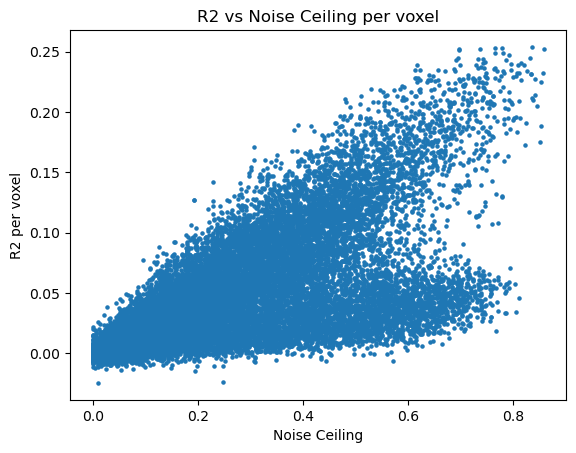

In [88]:
noise_ceiling = loader.noise_celing[str(args.subject_id[0])] / 100
plt.figure()

plt.scatter(noise_ceiling, r2_voxels, s=5)
plt.xlabel('Noise Ceiling')
plt.ylabel('R2 per voxel')
plt.title('R2 vs Noise Ceiling per voxel')
plt.savefig(f'figure/r2_vs_noise_ceiling_epochs{args.epochs}_bs{args.batch_size}_lr{args.lr_init}_decay{args.lr_decay}_wd{args.weight_decay}.png', dpi=300)
plt.show()


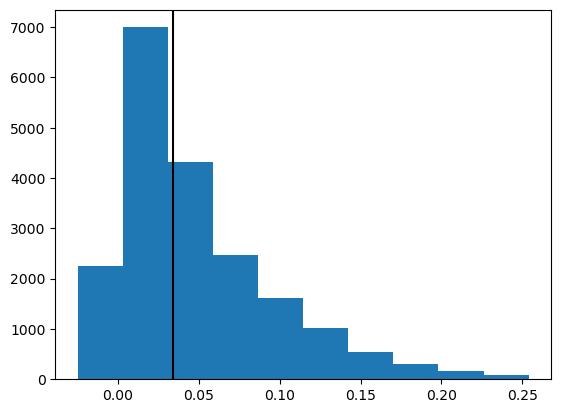

In [89]:
# histogram over voxels
# this is not very good.
# in theory if we train for more epochs, should get better R2.

plt.figure()
plt.hist(r2_voxels)
plt.axvline(np.median(r2_voxels), color='k')
plt.savefig(f'figure/r2_voxels_hist_epochs{args.epochs}_bs{args.batch_size}_lr{args.lr_init}_decay{args.lr_decay}_wd{args.weight_decay}.png', dpi=300)
plt.show()